# Amphistomy increases leaf photosynthesis more in coastal than montane plants of Hawaiian ʻilima (*Sida fallax*)

Reproduction of the **core statistical analysis** of Triplett, G. & Muir, C.D. (2024) *American Journal of Botany* **111(2):e16284**, doi:[10.1002/ajb2.16284](https://doi.org/10.1002/ajb2.16284). Author code: https://github.com/cdmuir/stomata-ilima (pinned commit `0a5477a91f23c8257fdb9552d5dd4c082789b9a7`).

**Scope / execution status**: PARTIAL demonstration. Re-runs the authors' own pinned R pipeline on the 12 measured leaves: raw LI-6800 A–gsw curves → gsw recalculation (`r/03_process-licor.R`) → Bayesian regression `A ~ log(gsw) * site_code_aperture` (`r/04_fit-licor.R`, brms 2.20.4 / CmdStan 2.33.1, seed 744874146, as in the paper's Methods) → amphistomy advantage AA = log(A_two-sided / A_one-sided) at matched gsw (`r/06_estimate-aa.R`) → coastal-vs-montane habitat comparison (`r/08` logic) compared against the published values (coastal AA 0.12, 95% CI 0.077–0.15; montane 0.027, CI −0.0034–0.057; difference 0.09). **Out of scope**: trait models (stomatal counts, gsmax,ratio, leaf thickness), climate tests, and manuscript rendering.

**AI note**: Python here is only a launcher. All scientific code is the authors' R scripts run **unmodified** from the pinned revision. The `v1.0` tag (`7f9d7dc`) was checked but its `r/functions.R` omits the `elapsed` column fix that the pipeline itself requires (verified by comparing tag…HEAD), so the pipeline runs at HEAD `0a5477a`. The authors did not provide this Colab wrapper; this executed example was validated, but untested behavior is not guaranteed.

**日本語**: 論文「アンフィストミー（両面気孔）が光合成を高める効果は海岸性植物でより大きい」の核心的統計解析の部分再現です。著者自身の R パイプライン（改変なし、リビジョン固定）を Colab の CPU ランタイムで実行し、AA を 12 葉から再推定して海岸 vs 山地の結果を論文値と照合します。形質モデル（気孔数・gsmax,ratio・葉厚）や気候解析、原稿ビルドは範囲外です。Python は起動役のみです。

## Runtime selection and Run all

**Select Runtime → Change runtime type → CPU** (the standard CPU runtime is recommended and sufficient; this analysis is a small CPU MCMC job with no GPU code path). Then **Runtime → Run all**.

Estimated durations (measured on the validation run noted in the report; free-tier times vary): R package installation ≈ 10 min, CmdStan 2.33.1 build ≈ 10–20 min, curve processing ≈ 1 min, brms fit ≈ 5–15 min, remainder ≈ 1 min. Downloads ≈ 60 MB (CmdStan toolchain + R packages + ~1.6 MB of data).

**日本語**: ランタイムは **CPU** を選択してください（GPU 不要）。その後「すべてのセルを実行」。所要時間の目安は上記の通りです。

In [ ]:
import shutil, subprocess, multiprocessing, time

def run_r(script, timeout=1800, cwd="/content"):
    """Run an R script file with Rscript, streaming its output into the notebook."""
    t0 = time.time()
    p = subprocess.Popen(["Rscript", script], cwd=cwd,
                         stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in p.stdout:
        print(line, end="", flush=True)
    rc = p.wait(timeout=timeout)
    if rc != 0:
        raise RuntimeError(f"{script} exited with {rc}")
    print(f"[{script}] OK in {time.time()-t0:.0f} s")

if shutil.which("Rscript") is None:
    print("Rscript not found; installing r-base ...")
    subprocess.run(["bash", "-c", "apt-get -qq update && apt-get -qq install -y r-base > /dev/null"], check=True)
ver = subprocess.run(["Rscript", "-e", "cat(R.version.string)"], capture_output=True, text=True, check=True).stdout
print("R runtime:", ver.strip())
print("CPUs:", multiprocessing.cpu_count())
with open("/proc/meminfo") as f:
    print("RAM:", next(f).strip())

R runtime: R version 4.6.1 (2026-06-24)
CPUs: 2
RAM: MemTotal:       13286944 kB


## R package installation

Installs the R packages the authors' `r/header.R` loads (their `r/install-packages.R` list; `raster` is omitted because no script on the selected path loads it). The paper's Methods pin **brms 2.20.4**, so that exact version is installed from the CRAN archive when it is not already present; other packages install at current CRAN versions.

**日本語**: 著者の `r/header.R` が必要とする R パッケージをインストールします。論文の Methods に合わせて **brms 2.20.4** をピン留めします（CRAN アーカイブから）。約10分かかります。

In [ ]:
R_INSTALL = r'''options(warn = 1)
if (!requireNamespace("remotes", quietly = TRUE)) install.packages("remotes")

# Pin brms 2.20.4 (paper Methods); remotes resolves its dependencies from CRAN.
# Fall back to the current CRAN release if the pinned build is unavailable.
if (!requireNamespace("brms", quietly = TRUE) || packageVersion("brms") != "2.20.4") {
  ok <- !inherits(
    try(remotes::install_version("brms", version = "2.20.4",
                                 repos = "https://cloud.r-project.org",
                                 upgrade = "never", quiet = TRUE), silent = TRUE),
    "try-error")
  if (!ok || !requireNamespace("brms", quietly = TRUE)) {
    message("brms 2.20.4 unavailable; installing current CRAN brms")
    install.packages("brms")
  }
}
cat("brms:", as.character(packageVersion("brms")), "\n")

pkgs <- c("checkmate","cowplot","dplyr","forcats","ggdist","ggplot2","ggpp","ggpubr",
          "glue","gridExtra","magrittr","photosynthesis","purrr","readr","rstatix",
          "stringr","tidybayes","tidyr")
for (p in pkgs) if (!requireNamespace(p, quietly = TRUE)) install.packages(p)
for (p in pkgs) cat(p, as.character(packageVersion(p)), "\n")
'''
with open("/content/install_packages.R", "w") as f:
    f.write(R_INSTALL)
run_r("/content/install_packages.R", timeout=2400)

Installing package into ‘/usr/local/lib/R/site-library’


(as ‘lib’ is unspecified)


trying URL 'https://cran.rstudio.com/src/contrib/remotes_2.5.0.tar.gz'


Content type 'application/x-gzip' length 164496 bytes (160 KB)


downloaded 160 KB


...

rstatix 1.1.0 


stringr 1.6.0 


tidybayes 3.0.7 


tidyr 1.3.2 


[/content/install_packages.R] OK in 1956 s


## CmdStan toolchain (brms backend)

`r/04_fit-licor.R` uses `backend = "cmdstanr"`. Installs **cmdstanr** and builds **CmdStan 2.33.1** (the exact version stated in the paper's Methods). The C++ build is the longest single step.

**日本語**: brms のバックエンドとして論文と同じ **CmdStan 2.33.1** をビルドします（最長の工程、目安10–20分）。

In [ ]:
R_CMDSTAN = r'''options(warn = 1)
if (!requireNamespace("cmdstanr", quietly = TRUE)) {
  install.packages("cmdstanr", repos = c("https://mc-stan.org/r-packages/", getOption("repos")))
}
library(cmdstanr)
install_cmdstan(version = "2.33.1", quiet = FALSE)
cat("cmdstan:", cmdstan_version(), "\n")
cat("cmdstanr:", as.character(packageVersion("cmdstanr")), "\n")
'''
with open("/content/install_cmdstan.R", "w") as f:
    f.write(R_CMDSTAN)
run_r("/content/install_cmdstan.R", timeout=2700)
print("CmdStan ready")

Installing package into ‘/usr/local/lib/R/site-library’


(as ‘lib’ is unspecified)


trying URL 'https://mc-stan.org/r-packages/src/contrib/cmdstanr_0.8.0.tar.gz'


Content type 'application/gzip' length 853201 bytes (833 KB)


downloaded 833 KB


...

* Finished installing CmdStan to /root/.cmdstan/cmdstan-2.33.1


CmdStan path set to: /root/.cmdstan/cmdstan-2.33.1


cmdstan: 2.33.1 


cmdstanr: 0.8.0 


[/content/install_cmdstan.R] OK in 401 s
CmdStan ready


## Input data: pinned partial clone of the author repository (inside Colab only)

All inputs live in the author repository: 13 raw LI-6800 log files (`raw-data/licor/`, ~1.6 MB total), the raw trait CSVs, and the `r/` scripts. A blobless partial clone with sparse checkout fetches **only** `raw-data/`, `r/`, and `dryad/` at the pinned commit, and the checked-out commit is asserted. All repository/dataset bytes stay on the Colab VM.

**日本語**: 著者リポジトリの必要部分（raw-data・r・dryad）のみを、コミット固定の部分クローンで Colab 内に取得します。コミット一致を検証し、生データは Colab VM 外に置きません。

In [ ]:
import subprocess

COMMIT = "0a5477a91f23c8257fdb9552d5dd4c082789b9a7"  # HEAD of cdmuir/stomata-ilima
REPO = "/content/stomata-ilima"

sh = f'''set -e
git clone --filter=blob:none --no-checkout https://github.com/cdmuir/stomata-ilima.git {REPO}
cd {REPO}
git sparse-checkout init --cone
git sparse-checkout set raw-data r dryad
git checkout {COMMIT}
mkdir -p processed-data objects figures  # gitignored output dirs the scripts write into
echo "checked out: $(git rev-parse HEAD)"
ls raw-data/licor/ | wc -l
du -sh raw-data
'''
subprocess.run(["bash", "-c", sh], check=True)

assert subprocess.run(["git", "rev-parse", "HEAD"], cwd=REPO,
                      capture_output=True, text=True).stdout.strip() == COMMIT
# Guard against Git LFS pointer stubs: real log files are plain text, not "version https://git-lfs"
head = open(f"{REPO}/raw-data/licor/2022-08-07-0716_logdata").readline()
assert not head.startswith("version https://git-lfs"), "unexpected LFS pointer file"
print("pinned commit verified; 13 LI-6800 log files expected, LFS-pointer check passed")

pinned commit verified; 13 LI-6800 log files expected, LFS-pointer check passed


## Input preview

Quick validation of the downloaded bytes against the authors' documented schema (`dryad/README.md`: 185 rows × 32 columns; 12 sites; 13 curve files) before any analysis.

**日本語**: 解析前にダウンロードしたデータを検証します（Dryad README 通りの行数・列数、13 曲線ファイル、サイト表）。

In [ ]:
R_PREVIEW = r'''suppressPackageStartupMessages({library(readr); library(dplyr)})
site <- read_csv("raw-data/site.csv", show_col_types = FALSE)
cat("sites:", nrow(site), "\n")
print(as.data.frame(site[, c("site_code", "site_type", "island", "elevation_m")]))

dryad <- read_csv("dryad/stomata-ilima.csv", show_col_types = FALSE)
cat("dryad rows x cols:", nrow(dryad), "x", ncol(dryad), "\n")
# 185 rows expected; this commit carries 27 columns (the Dryad deposit doi:10.5061/DRYAD.RXWDBRVFW documents 32)
stopifnot(nrow(dryad) == 185)

lf <- list.files("raw-data/licor", full.names = TRUE)
stopifnot(length(lf) == 13)
cat("licor log files:", length(lf), " total bytes:", sum(file.size(lf)), "\n")
'''
with open(f"/content/stomata-ilima/preview.R", "w") as f:
    f.write(R_PREVIEW)
run_r("preview.R", cwd="/content/stomata-ilima", timeout=600)

sites: 13 


   site_code site_type island elevation_m


1       mkpb   coastal   oahu      3.0480


2       hwlr   montane   oahu    351.7392


3       kgma   montane hawaii   1946.1480


...

12      knpn   coastal   oahu      4.2672


13      mmrd   montane   oahu    248.4120


dryad rows x cols: 185 x 27 


licor log files: 13  total bytes: 1569521 


[preview.R] OK in 2 s


## Author pipeline step 1: trait joins and curve processing

Runs the authors' scripts **unmodified** from the repo root with `Rscript`:

- `r/02_process-trait-data.R` — reads the raw CSVs, applies the authors' assertion checks, writes `processed-data/site.rds` and `processed-data/trait.rds`.
- `r/03_process-licor.R` — reads the 13 raw LI-6800 log files with `photosynthesis::read_licor`, recalculates gsw with the authors' `recalc_licor` (leaf area S = 6/6 cm², K = 0 for one-sided and 0.5 for two-sided apertures, thermocouple T_leaf, `use_EB = FALSE`), writes `processed-data/licor.rds`.

**日本語**: 著者のスクリプトを改変なしで実行します（02: 生データの結合と検証、03: LI-6800 曲線の gsw 再計算）。

In [ ]:
# The streaming runner run_r() was defined in the environment-check cell above.
run_r("r/02_process-trait-data.R", cwd="/content/stomata-ilima", timeout=900)
run_r("r/03_process-licor.R", cwd="/content/stomata-ilima", timeout=1800)

Loading required package: Rcpp


Loading 'brms' package (version 2.20.4). Useful instructions


can be found by typing help('brms'). A more detailed introduction


to the package is available through vignette('brms_overview').


Attaching package: ‘brms’


...

• `TIME` -> `TIME...116`


• `time` -> `time...167`


• `hhmmss` -> `hhmmss...168`


• `` -> `...293`


[r/03_process-licor.R] OK in 13 s


## Author pipeline step 2: Bayesian fit of A vs log(gsw)

Runs `r/04_fit-licor.R` unmodified: `brm(A ~ log(gsw) * site_code_aperture, sigma ~ 1 + (1|site_code_aperture))`, iter 4000, thin 2, 4 chains, seed 744874146, `backend = "cmdstanr"` — exactly the model in the paper's Methods. Writes `objects/fit_licor.rds`. Colab CPUs have 2 cores while the script requests 4, so chains oversubscribe harmlessly.

**日本語**: 論文の Methods どおりのベイズ回帰（brms 2.20.4 / CmdStan 2.33.1、seed 固定）を著者スクリプトのまま実行します。Colab の CPU コア数が 2 のためチェーンがオーバーサブスクライブしますが問題ありません。

In [ ]:
run_r("r/04_fit-licor.R", cwd="/content/stomata-ilima", timeout=3600)

Loading required package: Rcpp


Loading 'brms' package (version 2.20.4). Useful instructions


can be found by typing help('brms'). A more detailed introduction


to the package is available through vignette('brms_overview').


Attaching package: ‘brms’


...

All 4 chains finished successfully.


Mean chain execution time: 1005.7 seconds.


Total execution time: 1073.1 seconds.


See https://mc-stan.org/misc/warnings for details.


[r/04_fit-licor.R] OK in 1134 s


## Author pipeline step 3: amphistomy advantage (AA) per leaf

Runs `r/06_estimate-aa.R` unmodified: interpolates both aperture treatments at a common gsw (overlap region of each curve pair), predicts A from the posterior for every draw, and computes **AA = log(A_two-sided / A_one-sided)** per leaf. Then prints a per-leaf summary (median AA and 95% interval over posterior draws).

**日本語**: 著者の `r/06_estimate-aa.R` を実行し、共通 gsw での A を事後分布から予測して **AA = log(A_両面 / A_片面)** を葉ごとに推定します（中央値と95%区間を表示）。

In [ ]:
run_r("r/06_estimate-aa.R", cwd="/content/stomata-ilima", timeout=1800)

R_AASUM = r'''suppressPackageStartupMessages({library(brms); library(dplyr); library(readr); library(tidyr)})
aa <- read_rds("objects/aa.rds")
stopifnot(nrow(distinct(aa, site_code)) == 12, all(c("site_code", "draw", "AA") %in% names(aa)))
aa_summary <- aa |> group_by(site_code) |>
  summarise(AA_median = median(AA), AA_lo = quantile(AA, 0.025), AA_hi = quantile(AA, 0.975), .groups="drop")
print(as.data.frame(aa_summary))
write_csv(aa_summary, "objects/aa_per_leaf_summary.csv")
'''
with open("/content/stomata-ilima/aa_summary.R", "w") as f:
    f.write(R_AASUM)
run_r("aa_summary.R", cwd="/content/stomata-ilima", timeout=900)
print("per-leaf AA summary written to objects/aa_per_leaf_summary.csv")

Loading required package: Rcpp


Loading 'brms' package (version 2.20.4). Useful instructions


can be found by typing help('brms'). A more detailed introduction


to the package is available through vignette('brms_overview').


Attaching package: ‘brms’


...

9       mkpb  0.03786143 -0.05051958  0.130670797


10      mmrd  0.11133923  0.07953340  0.143677919


11      pkpp  0.15003520  0.12736788  0.172911971


12      whlr -0.03001468 -0.05145804 -0.008384699


[aa_summary.R] OK in 7 s
per-leaf AA summary written to objects/aa_per_leaf_summary.csv


## Habitat comparison and check against the published result

Applies the authors' habitat-level aggregation from `r/08_plot-habitat-aa.R` (mean AA per habitat over each posterior draw), then compares the posterior medians and 95% intervals with the published values: **coastal AA 0.12 (95% CI 0.077–0.15), montane 0.027 (CI −0.0034–0.057), difference 0.09** (Results, 'Amphistomy advantage is greater in coastal leaves'). Expect small Monte Carlo / version-dependent differences, not digit-for-digit equality.

**日本語**: 著者の `r/08` の集計（ドローごとの生息地平均）を適用し、論文記載値（海岸 0.12 [0.077–0.15]、山地 0.027 [−0.0034–0.057]、差 0.09）と比較します。MCMC・バージョン差による小さな揺らぎは許容します。

In [ ]:
R_HAB = r'''suppressPackageStartupMessages({library(brms); library(dplyr); library(readr)})
site <- read_rds("processed-data/site.rds")
aa <- read_rds("objects/aa.rds")

habitat_aa <- aa |>
  select(site_code, draw, AA) |>
  left_join(select(site, site_code, site_type), by = join_by(site_code)) |>
  summarize(AA = mean(AA), .by = c("site_type", "draw"))   # author r/08 aggregation

hab <- habitat_aa |> group_by(site_type) |>
  summarise(AA_median = median(AA), AA_lo = quantile(AA, 0.025), AA_hi = quantile(AA, 0.975), .groups="drop")
print(as.data.frame(hab))

diff_aa <- habitat_aa |>
  summarize(AA = AA[site_type == "coastal"] - AA[site_type == "montane"], .by = draw)
cat("coastal - montane: median", median(diff_aa$AA),
    "95% CI", quantile(diff_aa$AA, 0.025), "to", quantile(diff_aa$AA, 0.975), "\n")

published <- data.frame(site_type = c("coastal","montane"),
                        paper_AA = c(0.12, 0.027),
                        paper_lo = c(0.077, -0.0034), paper_hi = c(0.15, 0.057))
print(merge(as.data.frame(hab), published, by = "site_type"))
write_csv(hab, "objects/habitat_aa_summary.csv")
'''
with open("/content/stomata-ilima/habitat_aa.R", "w") as f:
    f.write(R_HAB)
run_r("habitat_aa.R", cwd="/content/stomata-ilima", timeout=900)
print("habitat summary written to objects/habitat_aa_summary.csv")

  site_type  AA_median        AA_lo      AA_hi


1   coastal 0.11676030  0.078621781 0.15471647


2   montane 0.02693342 -0.005633673 0.05821361


coastal - montane: median 0.08999343 95% CI 0.03939604 to 0.138778 


  site_type  AA_median        AA_lo      AA_hi paper_AA paper_lo paper_hi


1   coastal 0.11676030  0.078621781 0.15471647    0.120   0.0770    0.150


2   montane 0.02693342 -0.005633673 0.05821361    0.027  -0.0034    0.057


[habitat_aa.R] OK in 7 s
habitat summary written to objects/habitat_aa_summary.csv


## Visualization (created for this notebook)

Per-leaf AA posterior medians with 95% intervals, grouped by habitat (coastal/montane), mirroring the authors' Figure 2 layout but regenerated here from this run's outputs — **not** an author figure and not a reproduced published result.

**日本語**: 今回の実行結果から再生成した図（著者の Fig. 2 の構成に対応。著者の図そのものではありません）。

saved objects/aa_habitat.png


[plot_aa.R] OK in 8 s


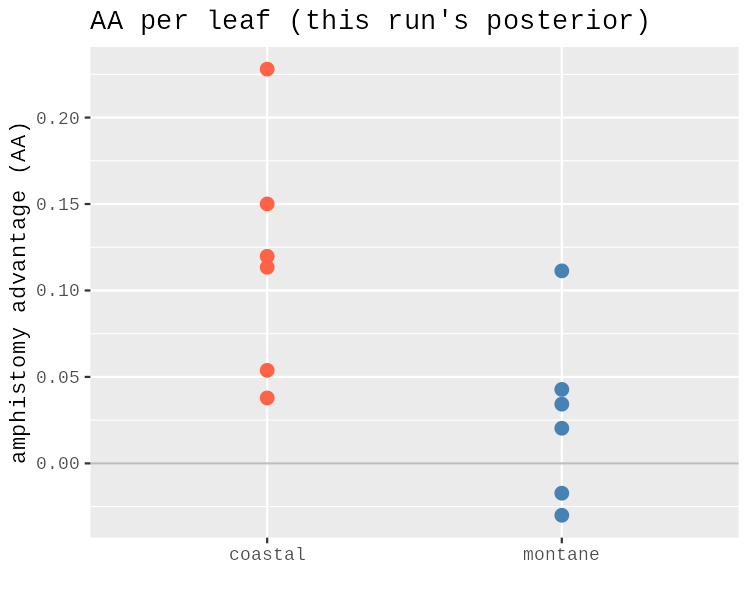

In [ ]:
R_PLOT = r'''suppressPackageStartupMessages({library(brms); library(dplyr); library(readr); library(ggplot2)})
aa <- read_rds("objects/aa.rds")
site <- read_rds("processed-data/site.rds")
df1 <- aa |> group_by(site_code) |>
  summarise(AA = median(AA), lo = quantile(AA, 0.025), hi = quantile(AA, 0.975), .groups="drop") |>
  left_join(select(site, site_code, site_type), by = join_by(site_code))
write_csv(df1, "objects/aa_plot_data.csv")
p <- ggplot(df1, aes(site_type, AA, ymin = lo, ymax = hi, color = site_type)) +
  geom_hline(yintercept = 0, color = "grey") +
  geom_pointrange(position = position_dodge(width = 0.5)) +
  ylab("amphistomy advantage (AA)") + xlab("") +
  scale_color_manual(values = c(coastal = "tomato", montane = "steelblue"), guide = "none") +
  ggtitle("AA per leaf (this run's posterior)")
ggsave("objects/aa_habitat.png", p, width = 5, height = 4, dpi = 150)
cat("saved objects/aa_habitat.png\n")
'''
with open("/content/stomata-ilima/plot_aa.R", "w") as f:
    f.write(R_PLOT)
run_r("plot_aa.R", cwd="/content/stomata-ilima", timeout=900)

from IPython.display import Image, display
display(Image(filename="/content/stomata-ilima/objects/aa_habitat.png"))

## Session record

Prints the exact R and package versions used by this run for reproducibility.

**日本語**: 再現性のため、実行に使った R とパッケージのバージョンを記録します。

In [ ]:
R_SESS = r'''cat(R.version.string, "\n")
print(packageVersion("brms")); print(cmdstanr::cmdstan_version())
print(sessionInfo()$otherPkgs)
'''
with open("/content/stomata-ilima/session.R", "w") as f:
    f.write(R_SESS)
run_r("session.R", cwd="/content/stomata-ilima", timeout=300)

R version 4.6.1 (2026-06-24) 


[1] ‘2.20.4’


[1] "2.33.1"


NULL


[session.R] OK in 1 s


## Interpretation, differences from the paper, and references

- **What this demonstrates**: the authors' own pinned pipeline (curve processing → Bayesian `A ~ log(gsw)` fit → AA per leaf → habitat aggregation) runs end-to-end in Colab and should reproduce the paper's central finding — coastal (sun) leaves show a clearly positive amphistomy advantage and a larger habitat-level AA than montane (shade) leaves — within Monte Carlo tolerance of the published values.
- **Known differences from the paper**: (1) this is a partial demonstration — trait models (`gsmax,ratio`, leaf thickness), climate tests, and the manuscript build are omitted; (2) CmdStan 2.33.1 and brms 2.20.4 are pinned per the Methods, but the R runtime and CRAN package versions may differ from the authors' R 4.3.1, and Colab provides 2 cores where the scripts request 4; (3) the pipeline runs at commit `0a5477a` rather than the `v1.0` tag (the tag's `r/functions.R` lacks the `elapsed` column its own pipeline selects); (4) posterior intervals vary by draw, so exact digits differ.
- **License note**: the GitHub repository has no LICENSE file (the Zenodo archive is CC-BY-4.0). Code is shown here via the pinned public repository for scholarly reproduction; check with the authors before reuse.
- **References**: Triplett & Muir 2024, Am. J. Bot. 111(2):e16284, doi:10.1002/ajb2.16284; code/data github.com/cdmuir/stomata-ilima (commit `0a5477a`) and doi:10.5061/DRYAD.RXWDBRVFW; methods: Sack & Buckley 2016 (gsmax framing), brms/CmdStan documentation.

**日本語**: 本ノートブックは部分的な再現であり、形質モデル・気候解析・原稿ビルドは範囲外です。バージョン差と MCMC 揺らぎのため数値は論文と完全一致しません。